Datos estadisticos en compras

In [ ]:

import pandas as pd
import numpy as np
import scipy.stats as stats

#Cargamos dataset
df = pd.read_csv("dataset_compras_clientes.csv")

In [ ]:
#Media real
media_poblacional = df["gasto_cliente"].mean()
print(f"La media real de la poblacion es: {media_poblacional:.2f}\n")

La media real de la poblacion es: 451.16



In [ ]:
#Lista de muestras
resultados = []
tamanos_de_muestra = [30, 60, 100]

for n in tamanos_de_muestra:
  #Aleatoria
  muestra = df.sample(n=n, random_state=42)
  #Media y desviacion estandar
  media_muestral = muestra["gasto_cliente"].mean()
  desviacion = muestra["gasto_cliente"].std()
  #Error estandar
  error_estandar = desviacion / np.sqrt(n)
  #Intervalo de confianza
  limite_inferior, limite_superior = stats.t.interval(
        confidence=0.95, #Confianza 95
        df=n-1, #Libertad
        loc=media_muestral,  #Media
        scale=error_estandar #Error
    )

  #Guardamos datos
  resultados.append({
        "Tamaño de muestra": n,
        "Media muestral": media_muestral,
        "I Inferior (95%)": limite_inferior,
        "I Superior (95%)": limite_superior
    })

  #Tabla comparativa
  tabla_final = pd.DataFrame(resultados)
tabla_final = tabla_final.round(2)
print("--- TABLA COMPARATIVA ---")
print(tabla_final)



--- TABLA COMPARATIVA ---
   Tamaño de muestra  Media muestral  I Inferior (95%)  I Superior (95%)
0                 30          448.22            430.86            465.59
1                 60          442.06            429.41            454.71
2                100          450.30            439.28            461.33


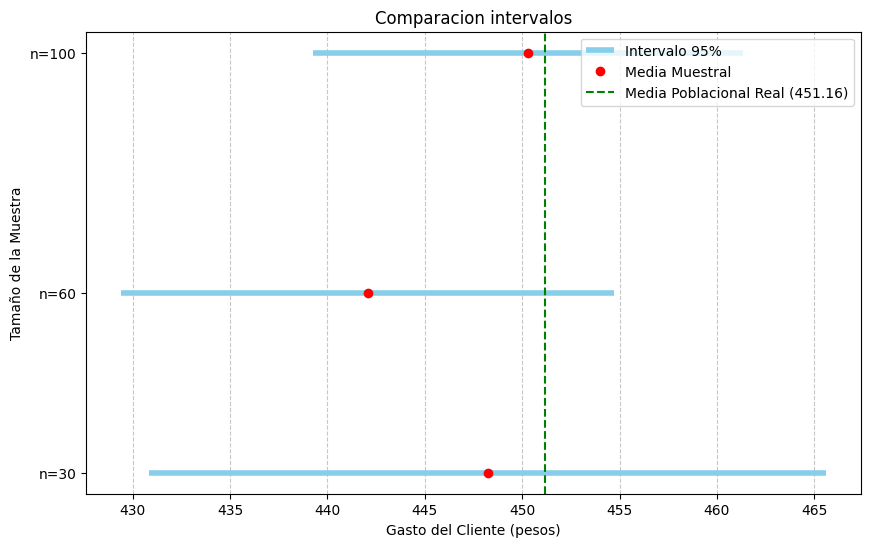

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

#Intervalo de confianza
for i, fila in tabla_final.iterrows():
    plt.hlines(y=fila['Tamaño de muestra'], xmin=fila['I Inferior (95%)'],
               xmax=fila['I Superior (95%)'], color='skyblue', linewidth=4, label='Intervalo 95%' if i == 0 else "")

    #Media muestral
    plt.plot(fila['Media muestral'], fila['Tamaño de muestra'], 'ro', label='Media Muestral' if i == 0 else "")

#Media real
plt.axvline(media_poblacional, color='green', linestyle='--', label=f'Media Poblacional Real ({media_poblacional:.2f})')


plt.yticks([30, 60, 100], ['n=30', 'n=60', 'n=100'])
plt.xlabel('Gasto del Cliente (pesos)')
plt.ylabel('Tamaño de la Muestra')
plt.title('Comparacion intervalos')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()